# PD controller test
This notebook runs a ClosedLoop simulation using the PD controller and plots reference, depth, and control action.

In [7]:
# Ensure project root is on sys.path so 'uuv_mission' can be imported even if the kernel was started elsewhere
import sys, pathlib
root = pathlib.Path().resolve()
# walk up until we find the package directory 'uuv_mission' or reach the filesystem root
while not (root / 'uuv_mission').exists() and root.parent != root:
    root = root.parent
sys.path.insert(0, str(root))
print('Added to sys.path:', str(root))

Added to sys.path: /home/vivek/Documents/b1-coding-practical-mt24


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from uuv_mission.dynamic import Mission, Submarine, ClosedLoop
from uuv_mission.control import PDController

In [10]:
# Load mission using the absolute path discovered in the sys.path helper cell
mission = Mission.from_csv(str(root / 'data' / 'mission.csv'))
plant = Submarine()
controller = PDController(kp=0.15, kd=0.6)
cl = ClosedLoop(plant, controller)
traj = cl.simulate_with_random_disturbances(mission, variance=0.5)

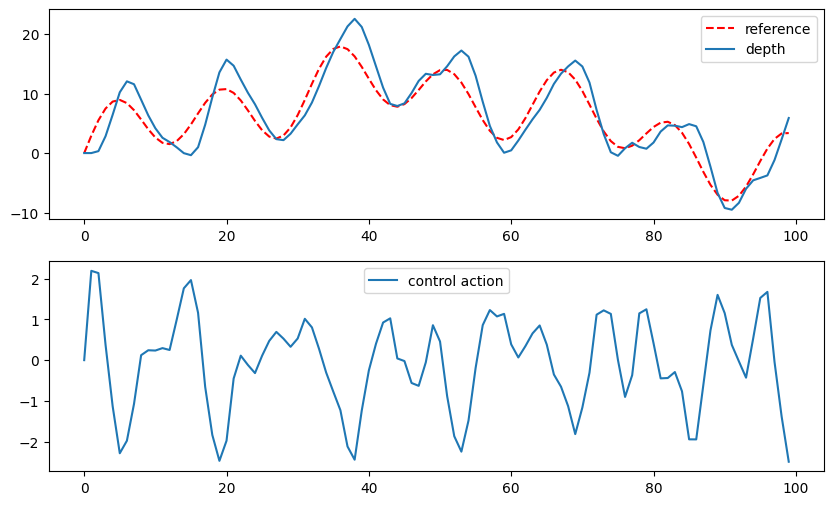

In [ ]:
# Plot depth (y) vs reference, and actions with cave boundaries
T = len(mission.reference)
x = np.arange(T)
depth = traj.position[:,1]
actions = traj.actions
plt.figure(figsize=(10,8))
plt.subplot(2,1,1)
# Draw cave bounds background
plt.fill_between(x, mission.cave_height, mission.cave_depth, color='lightsteelblue', alpha=0.4, label='cave bounds')
plt.plot(x, mission.reference, 'r--', label='reference')
plt.plot(x, depth, label='depth')
plt.ylim(np.min(mission.cave_depth) - 5, np.max(mission.cave_height) + 5)
plt.xlabel('time step')
plt.ylabel('depth')
plt.legend(loc='upper right')
plt.subplot(2,1,2)
plt.plot(x, actions, label='control action')
plt.xlabel('time step')
plt.ylabel('control action')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()